# Assignment 1: Explainable AI for Protein Biology 

**Course:** Advanced Machine Learning for the Life Sciences (MBioAML)
**Dataset:** Extracellular Vesicle (EV) Protein Sorting
**Environment:** Google Colab (CPU runtime is sufficient)

---

## Overview

Machine learning models can predict complex biological outcomes — such as whether a protein is sorted into extracellular vesicles — with high accuracy. But in biology, prediction alone is not enough. We need to understand *why* a model makes a decision: which features drive the prediction, and does that align with known biology?

This assignment puts those ideas into practice. You will:

1. **Train** three models (Logistic Regression, Random Forest, MLP) on real protein biology data
2. **Visualize** global model behavior with PDP, ICE, ALE, and permutation importance
3. **Explain** individual predictions with **LIME** — and explore how its hyperparameters affect results
4. **Explain** with **SHAP** using model-agnostic methods (Sampling, Permutation, Kernel SHAP)
5. **Explain** with **model-specific SHAP** (TreeSHAP, DeepSHAP) and compare speed/reliability
6. **Reflect** on what each method reveals about the biology of EV protein sorting

---

## The Dataset: Extracellular Vesicle Protein Sorting

Extracellular vesicles (EVs) are small membrane-bound particles released by cells. They carry proteins, lipids, and nucleic acids and play key roles in cell-to-cell communication, immune signalling, and even cancer metastasis. Understanding *which proteins* get sorted into EVs — and what makes them EV-destined — is a major open question in cell biology.

**Task:** Binary classification — predict whether a protein will be sorted into EVs (`EV = 1`) or not (`EV = 0`) from protein biochemical and bioinformatic features.

**Features (93 total) include:**
- Physicochemical properties: length, molecular weight, hydrophobicity, isoelectric point, charge, GRAVY index
- Amino acid composition (20 amino acid frequencies)
- Secondary structure fractions (helix, sheet, turn)
- Surface accessibility: total/relative accessible surface area, exposed residue fractions
- Post-translational modifications (PTMs): phosphorylation, ubiquitination, glycosylation, etc.
- Protein domain annotations: coiled-coil, transmembrane, EGF, RRM, etc.
- Solubility and aggregation propensity scores

---

## How to read this notebook

- **Explanatory cells** (like this one) introduce each concept and explain *why* we do things.
- **Code cells** contain the implementation — read them carefully before running.
- Cells marked with ✏️ **STUDENT TASK** require you to write code or answer questions.
- Questions marked **Q** should be answered directly in the notebook (add a markdown cell or use the provided answer box).

> ⚠️ **Colab note:** Run cells top-to-bottom. If your runtime disconnects, restart from Section 0.

---

## Table of Contents

| Section | Topic |
|---------|-------|
| [0. Setup](#setup) | Install packages, set seeds |
| [1. Data](#data) | Load, explore, and understand the EV dataset |
| [2. Models](#models) | Train Logistic Regression, Random Forest, MLP |
| [⬛ Day 1 Assignment](#day1) |----- |
| [3. Global Explanations](#global) | PDP, ICE, ALE, Permutation Importance |
| [4. LIME](#lime) | Local explanations, perturbations, kernel, fidelity, complexity |
| [5. SHAP Agnostic](#shap-ag) | Kernel SHAP and background sample effects |
| [6. SHAP Specific](#shap-sp) | TreeSHAP, DeepSHAP; speed & reliability vs Kernel SHAP |
| [7. Synthesis](#synthesis) | Compare methods, biological interpretation |


---
## Section 0: Setup & Installation <a id='setup'></a>

We install all required packages in one go.  It may take 1–2 minutes.

> **Why so many packages?** LIME and SHAP each come with their own dependencies. `torch` is needed for the MLP. `alibi` and `PyALE` provide ALE plots. `interpret` gives us PDP and ICE. `matplotlib` and `seaborn` for all visualization.


In [62]:
# ── 0.1  Install all required packages ───────────────────────────────────────
# Run this cell first. All output is suppressed for readability.
# If a package fails to install, remove the '> /dev/null 2>&1' and re-run to see the error.

!pip install -q numpy pandas "scikit-learn>=1.3" matplotlib seaborn > /dev/null 2>&1
!pip install -q torch > /dev/null 2>&1
!pip install -q lime > /dev/null 2>&1
!pip install -q shap > /dev/null 2>&1
!pip install -q PyALE > /dev/null 2>&1
!pip install -q tqdm joblib > /dev/null 2>&1

print("✅ All packages installed.")

298768.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298774.41s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298779.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298785.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298791.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298796.76s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


✅ All packages installed.


In [1]:
# ── 0.2  Imports and global settings ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings, time, random, copy
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, RocCurveDisplay, confusion_matrix
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split

# LIME
from lime.lime_tabular import LimeTabularExplainer

# SHAP
import shap

print("✅ All imports successful.")

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

PyTorch device: cpu
✅ All imports successful.


---
## Section 1: Data Loading and Exploration <a id='data'></a>

### 1.1 Loading the data

We train on a large dataset of annotated proteins and evaluate on a held-out test set. The notebook now loads both files directly from this GitHub repository, so no manual upload step is needed when the repository is accessible from Colab.


In [2]:
# ── 1.1  Load train and test data directly from GitHub ───────────────────
GITHUB_OWNER = "Majeed7"
GITHUB_REPO = "MbioAML_Assignment"
GITHUB_BRANCH = "main"
DATA_SUBDIR = "train%3Atest"  # URL-encoded form of `train:test`

BASE_URL = f"https://raw.githubusercontent.com/{GITHUB_OWNER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATA_SUBDIR}"
train_url = f"{BASE_URL}/training_remaining.csv"
test_url = f"{BASE_URL}/test_Dhondt2021.csv"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

TARGET  = "EV"
ID_COL  = "id"
FEATURE_COLS = [c for c in train_df.columns if c not in [TARGET, ID_COL]]

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test  = test_df[TARGET].values

print(f"Training set : {X_train.shape[0]:,} samples  |  {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Feature list (first 10): {FEATURE_COLS[:10]}")
print(f"Training URL : {train_url}")
print(f"Test URL     : {test_url}")


Training set : 13,331 samples  |  93 features
Test set     : 1,426 samples
Feature list (first 10): ['length', 'hydr_count', 'polar_count', 'molecular_weight', 'helix', 'turn', 'sheet', 'A', 'C', 'D']
Training URL : https://raw.githubusercontent.com/Majeed7/MbioAML_Assignment/main/train%3Atest/training_remaining.csv
Test URL     : https://raw.githubusercontent.com/Majeed7/MbioAML_Assignment/main/train%3Atest/test_Dhondt2021.csv


### 1.2 Class balance

Class imbalance is common in biology datasets. An imbalanced dataset means a model can appear to perform well simply by predicting the majority class. We must check the label distribution before trusting any accuracy number.


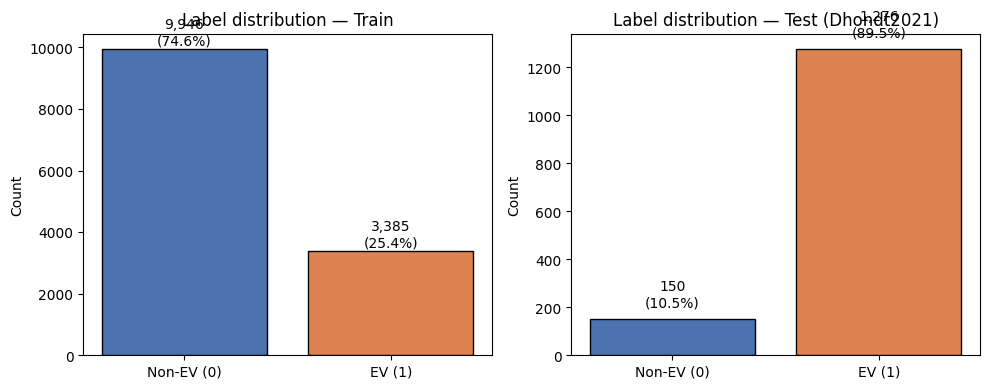

Train positive rate: 0.254
Test  positive rate: 0.895


In [ ]:
# ── 1.2  Class balance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (split_name, y) in zip(axes, [("Train", y_train), ("Test (Dhondt2021)", y_test)]):
    counts = np.bincount(y)
    bars = ax.bar(["Non-EV (0)", "EV (1)"], counts, color=["#4C72B0", "#DD8452"], edgecolor="black")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                f"{cnt:,}\n({100*cnt/len(y):.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Label distribution — {split_name}", fontsize=12)
    ax.set_ylabel("Count")

plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")


**Q1.** Is the dataset balanced? How will class imbalance affect model training and evaluation? Which metric is most reliable when classes are imbalanced — accuracy, F1, or AUC? Explain your reasoning.

> *Your answer here*


### Section 1.3: Correlation of features

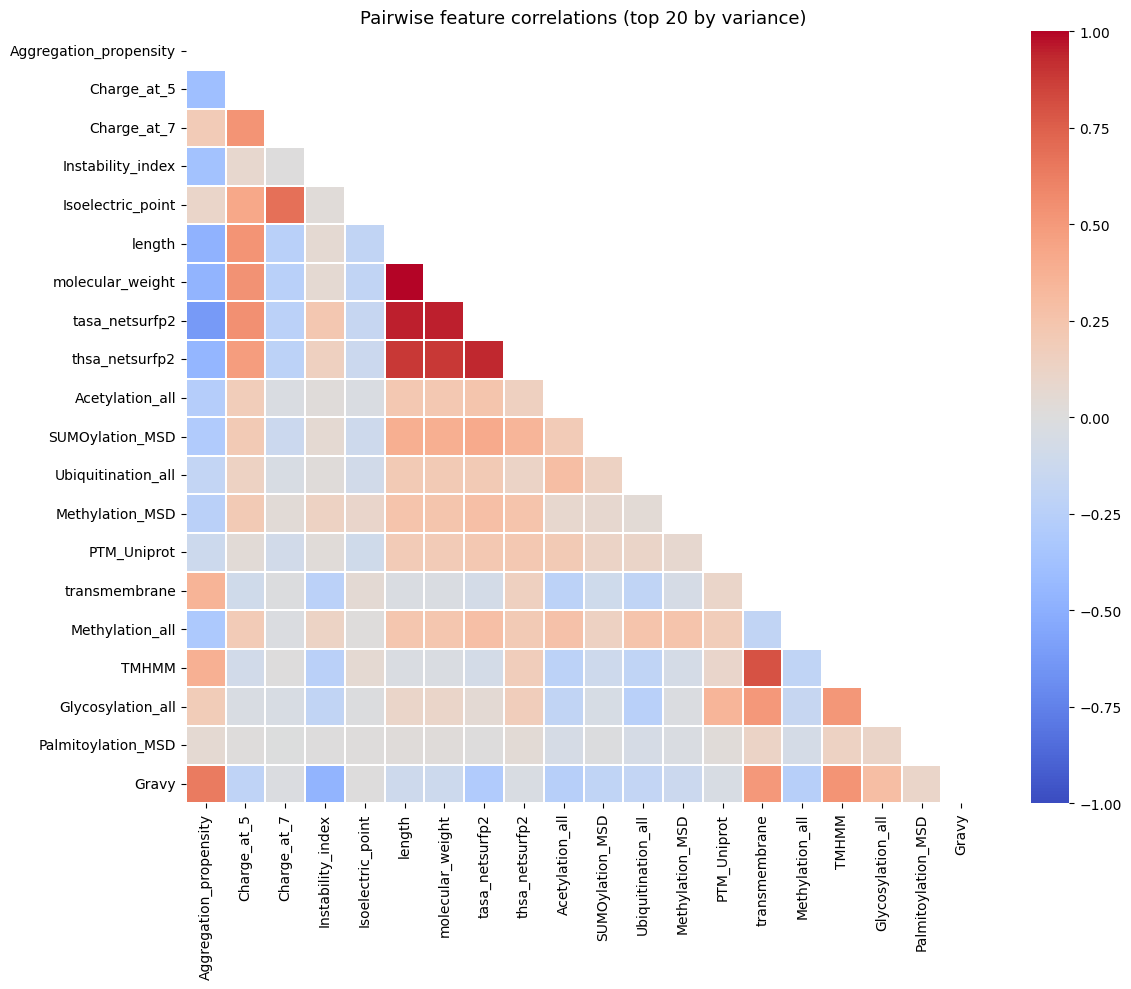

Highest absolute correlations:
molecular_weight        length                    0.999356
tasa_netsurfp2          length                    0.952216
molecular_weight        tasa_netsurfp2            0.950167
thsa_netsurfp2          tasa_netsurfp2            0.933299
length                  thsa_netsurfp2            0.889403
thsa_netsurfp2          molecular_weight          0.885359
transmembrane           TMHMM                     0.801779
Charge_at_7             Isoelectric_point         0.683621
Gravy                   Aggregation_propensity    0.639782
Aggregation_propensity  tasa_netsurfp2            0.618076


In [ ]:
# ── 1.4  Correlation heatmap (top 20 features by variance) ──────────────────
top_feat_idx = np.argsort(X_train.var(axis=0))[::-1][:20]
top_feat_names = [FEATURE_COLS[i] for i in top_feat_idx]
corr = pd.DataFrame(X_train[:, top_feat_idx], columns=top_feat_names).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pairwise feature correlations (top 20 by variance)", fontsize=13)
plt.tight_layout()
plt.savefig("feature_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Highest absolute correlations:")
corr_long = corr.abs().unstack().sort_values(ascending=False)
corr_long = corr_long[corr_long < 1.0].drop_duplicates()
print(corr_long.head(10).to_string())


---
## Section 2: Model Training <a id='models'></a>

We train three models of increasing complexity:

| Model | Why we use it |
|-------|--------------|
| **Logistic Regression** | giving probabilities; explaining the probabilities of the two classes |
| **Random Forest** | Non-linear ensemble; |
| **MLP (PyTorch)** | Deep network;  |

All models are trained on the same features and evaluated on the same test set. To incorporate class imbalance explicitly, we compute class weights from `y_train` and reuse those weights in Logistic Regression, Random Forest, and the MLP loss.



### 2.1 Logistic Regression
We train a logistic regression in this section. The training has not taken into account the class imbalance (and you need to take care of it!)

In [6]:
# ── 2.1  Logistic Regression ──────────────────────────────────────────────────
# Compute class weights from the training split only.
class_counts = np.bincount(y_train)
class_weight_dict = {
    0: len(y_train) / (class_counts[0]),
    1: len(y_train) / (class_counts[1]),
}
print(f"Training class counts: Non-EV={class_counts[0]:,}, EV={class_counts[1]:,}")
print(f"Class weights used: {class_weight_dict}")

# We wrap with a StandardScaler — LR is sensitive to feature scale.
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=0.4,          # regularization
        random_state=SEED
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

print("Logistic Regression — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"  F1   : {f1_score(y_test, lr_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds, target_names=["Non-EV","EV"]))


Training class counts: Non-EV=9,946, EV=3,385
Class weights used: {0: np.float64(1.3403378242509552), 1: np.float64(3.9382570162481536)}
Logistic Regression — Test set performance
  AUC  : 0.8258
  F1   : 0.9125
  Acc  : 0.8485
              precision    recall  f1-score   support

      Non-EV       0.36      0.56      0.44       150
          EV       0.94      0.88      0.91      1276

    accuracy                           0.85      1426
   macro avg       0.65      0.72      0.67      1426
weighted avg       0.88      0.85      0.86      1426



**Q** Looking at the performance of Logistic Regression:
- How is it with respect to the Non-EV class (minority)?
- Can you understand how the classes should be weighted (`class_weight_dict`)?
- Does adding class weight help the classification? To what extend?

### 2.2 Random Forest


In [15]:
# ── 2.2  Random Forest ───────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    max_features="sqrt",
    n_jobs=-1,
    random_state=SEED
)

rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random Forest — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"  F1   : {f1_score(y_test, rf_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=["Non-EV","EV"]))


Random Forest — Test set performance
  AUC  : 0.8330
  F1   : 0.8854
  Acc  : 0.8079
              precision    recall  f1-score   support

      Non-EV       0.30      0.63      0.41       150
          EV       0.95      0.83      0.89      1276

    accuracy                           0.81      1426
   macro avg       0.63      0.73      0.65      1426
weighted avg       0.88      0.81      0.84      1426



**Q** Compare the performance of random forest (with and without class weights) with logistic regression

### 2.3 MLP (PyTorch)

We build a small fully-connected network. The architecture is intentionally simple — three hidden layers with ReLU activations and dropout for regularization. We also build a **scikit-learn compatible wrapper** so that LIME (which expects a `predict_proba` function) can use this model without any modifications.


In [26]:
# ── 2.3a  MLP architecture ────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class EVNet(nn.Module):
    """
    Simple 3-layer MLP for EV protein classification.
    Output: single logit (apply sigmoid for probability).
    """
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            # nn.Linear(64, 32),
            # nn.ReLU(),
            # nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)   # shape: (B,)


INPUT_DIM = X_train.shape[1]
mlp = EVNet(INPUT_DIM).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP: {total_params:,} trainable parameters")
print(mlp)


MLP: 20,609 trainable parameters
EVNet(
  (net): Sequential(
    (0): Linear(in_features=93, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [27]:
# ── 2.3b  Preprocess: scale inputs ────────────────────────────────────────────
# The MLP shares the same scaler as Logistic Regression.
mlp_scaler = StandardScaler()
X_train_scaled = mlp_scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled  = mlp_scaler.transform(X_test).astype(np.float32)

# Use the same training-derived class imbalance information in the MLP loss.
pos_weight = torch.tensor([class_weight_dict[1] / class_weight_dict[0]], dtype=torch.float32).to(DEVICE)
print(f"MLP positive-class loss weight: {pos_weight.item():.3f}")

# Data loaders
train_tensor = TensorDataset(
    torch.tensor(X_train_scaled), torch.tensor(y_train, dtype=torch.float32))
test_tensor  = TensorDataset(
    torch.tensor(X_test_scaled),  torch.tensor(y_test,  dtype=torch.float32))

train_loader = DataLoader(train_tensor, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_tensor,  batch_size=512, shuffle=False)


MLP positive-class loss weight: 2.938


In [28]:
# ── 2.3c  Training loop ───────────────────────────────────────────────────────
def train_mlp(model, train_loader, n_epochs=30, lr=1e-3, pos_weight=None):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_loss = float("inf")
    best_state = None

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        epoch_loss /= len(train_loader)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d}/{n_epochs}  loss={epoch_loss:.4f}")

    model.load_state_dict(best_state)
    return model


print("Training MLP…")
mlp = train_mlp(mlp, train_loader, n_epochs=300, pos_weight=pos_weight)
print("Done.")


Training MLP…
  Epoch  50/300  loss=0.7145
  Epoch 100/300  loss=0.7153
  Epoch 150/300  loss=0.7148
  Epoch 200/300  loss=0.7142
  Epoch 250/300  loss=0.7149
  Epoch 300/300  loss=0.7159
Done.


In [29]:
# ── 2.3d  MLP evaluation + sklearn wrapper ────────────────────────────────────
def mlp_predict_proba(X: np.ndarray) -> np.ndarray:
    """
    sklearn-compatible predict_proba for the MLP.
    Accepts a raw (unscaled) numpy array, scales internally.
    Returns shape (N, 2): [P(non-EV), P(EV)].
    """
    X_sc = mlp_scaler.transform(X).astype(np.float32)
    with torch.no_grad():
        logits = mlp(torch.tensor(X_sc).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    return np.column_stack([1 - probs, probs])


mlp_probs = mlp_predict_proba(X_test)[:, 1]
mlp_preds = (mlp_probs >= 0.5).astype(int)

print("MLP — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, mlp_probs):.4f}")
print(f"  F1   : {f1_score(y_test, mlp_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, mlp_preds):.4f}")
print(classification_report(y_test, mlp_preds, target_names=["Non-EV","EV"]))


MLP — Test set performance
  AUC  : 0.7912
  F1   : 0.6071
  Acc  : 0.4909
              precision    recall  f1-score   support

      Non-EV       0.16      0.93      0.28       150
          EV       0.98      0.44      0.61      1276

    accuracy                           0.49      1426
   macro avg       0.57      0.68      0.44      1426
weighted avg       0.89      0.49      0.57      1426



### 2.4 Model comparison


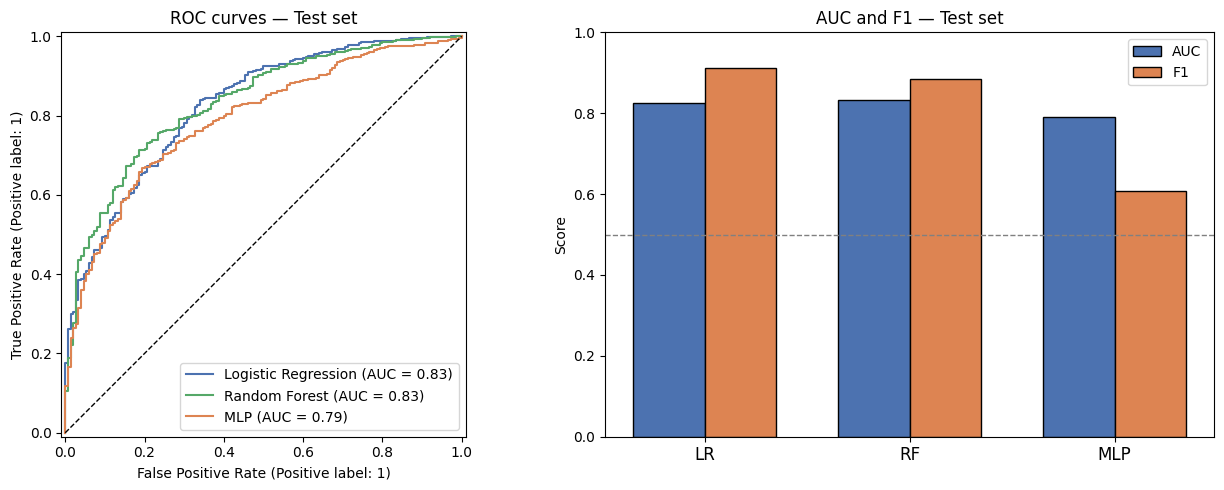

In [30]:
# ── 2.4  Compare all three models ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, probs, color in [
    ("Logistic Regression", lr_probs, "#4C72B0"),
    ("Random Forest",       rf_probs, "#55A868"),
    ("MLP",                 mlp_probs,"#DD8452"),
]:
    RocCurveDisplay.from_predictions(y_test, probs, name=name,
                                      ax=axes[0], color=color)
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_title("ROC curves — Test set")

# Bar chart: AUC / F1
models  = ["LR", "RF", "MLP"]
aucs = [roc_auc_score(y_test, p) for p in [lr_probs, rf_probs, mlp_probs]]
f1s  = [f1_score(y_test, p > .5)  for p in [lr_probs, rf_probs, mlp_probs]]

x = np.arange(len(models))
w = 0.35
axes[1].bar(x - w/2, aucs, w, label="AUC",  color="#4C72B0", edgecolor="black")
axes[1].bar(x + w/2, f1s,  w, label="F1",   color="#DD8452", edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, fontsize=12)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Score")
axes[1].set_title("AUC and F1 — Test set")
axes[1].legend(); axes[1].axhline(0.5, color="gray", lw=1, ls="--")

plt.tight_layout()
plt.show()


---
## Section 3: Global Explanations — PDP, ICE, ALE, Permutation Importance <a id='global'></a>

In the lectures, we introduced four global explanation methods. Here we apply all four to the EV protein dataset. Each method answers a slightly different question:

| Method | Question answered |
|--------|------------------|
| **Permutation Importance** | Which features, when scrambled, hurt the model most? |
| **PDP** | On average across all proteins, how does feature X affect predicted EV probability? |
| **ICE** | For *individual* proteins, how does the prediction change as we vary feature X? |
| **ALE** | Like PDP, but restricted to realistic feature regions — safer for correlated features |

We use the **Random Forest** as our reference model for this section because it is the best-performing non-linear model and natively supports TreeSHAP later.


### 3.1 Permutation Feature Importance

Permutation importance is model-agnostic and honest: it directly measures how much the model's test performance drops when a feature's information is destroyed. 


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

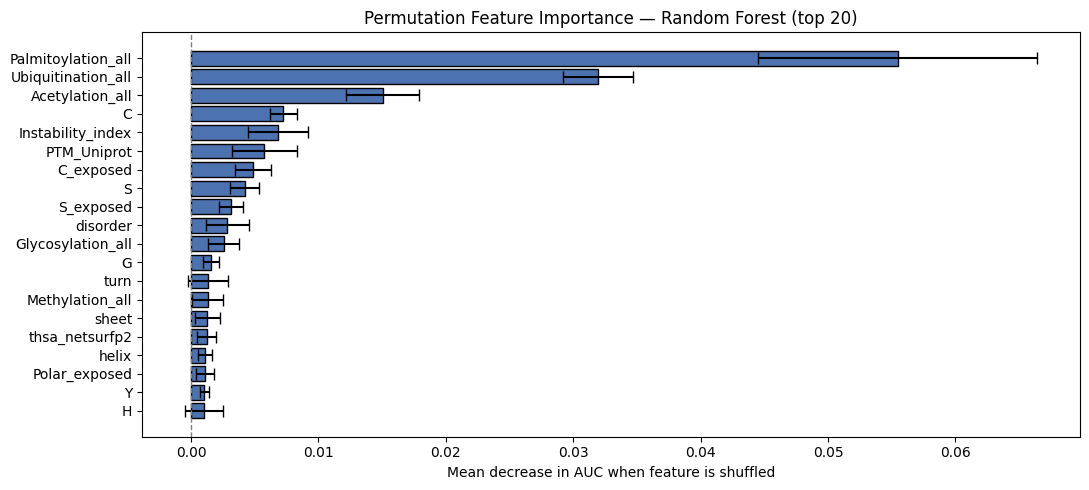

Top 10 features by permutation importance:
   1. Palmitoylation_all                   0.0555 ± 0.0110
   2. Ubiquitination_all                   0.0319 ± 0.0027
   3. Acetylation_all                      0.0150 ± 0.0029
   4. C                                    0.0073 ± 0.0011
   5. Instability_index                    0.0068 ± 0.0023
   6. PTM_Uniprot                          0.0057 ± 0.0026
   7. C_exposed                            0.0049 ± 0.0014
   8. S                                    0.0042 ± 0.0011
   9. S_exposed                            0.0031 ± 0.0009
  10. disorder                             0.0029 ± 0.0017


In [74]:
# ── 3.1  Permutation feature importance ──────────────────────────────────────
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1
)

# Sort by mean importance
perm_mean = perm_result.importances_mean
perm_std  = perm_result.importances_std
order     = np.argsort(perm_mean)[::-1][:20]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    [FEATURE_COLS[i] for i in order[::-1]],
    perm_mean[order[::-1]],
    xerr=perm_std[order[::-1]],
    color="#4C72B0", edgecolor="black", capsize=4
)
ax.set_xlabel("Mean decrease in AUC when feature is shuffled")
ax.set_title("Permutation Feature Importance — Random Forest (top 20)")
ax.axvline(0, color="gray", lw=1, ls="--")
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 10 features by permutation importance:")
for rank, i in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {FEATURE_COLS[i]:<35s}  {perm_mean[i]:.4f} ± {perm_std[i]:.4f}")


**Q4.** Which features are most important according to permutation importance? Can you interpret 2–3 of the top features biologically?

> *Your answer here*


### 3.2 Partial Dependence Plots (PDP) and ICE

PDPs show the *average* predicted EV probability across the full training set as one feature varies. ICE plots show the same but for *individual proteins*, revealing heterogeneity that the average hides.

Recall the key limitation: PDP averages over the entire data, including potentially unrealistic feature combinations (especially when features are correlated).



PDP/ICE on top-5 features: ['Palmitoylation_all', 'Ubiquitination_all', 'PTM_Uniprot', 'Instability_index', 'C']


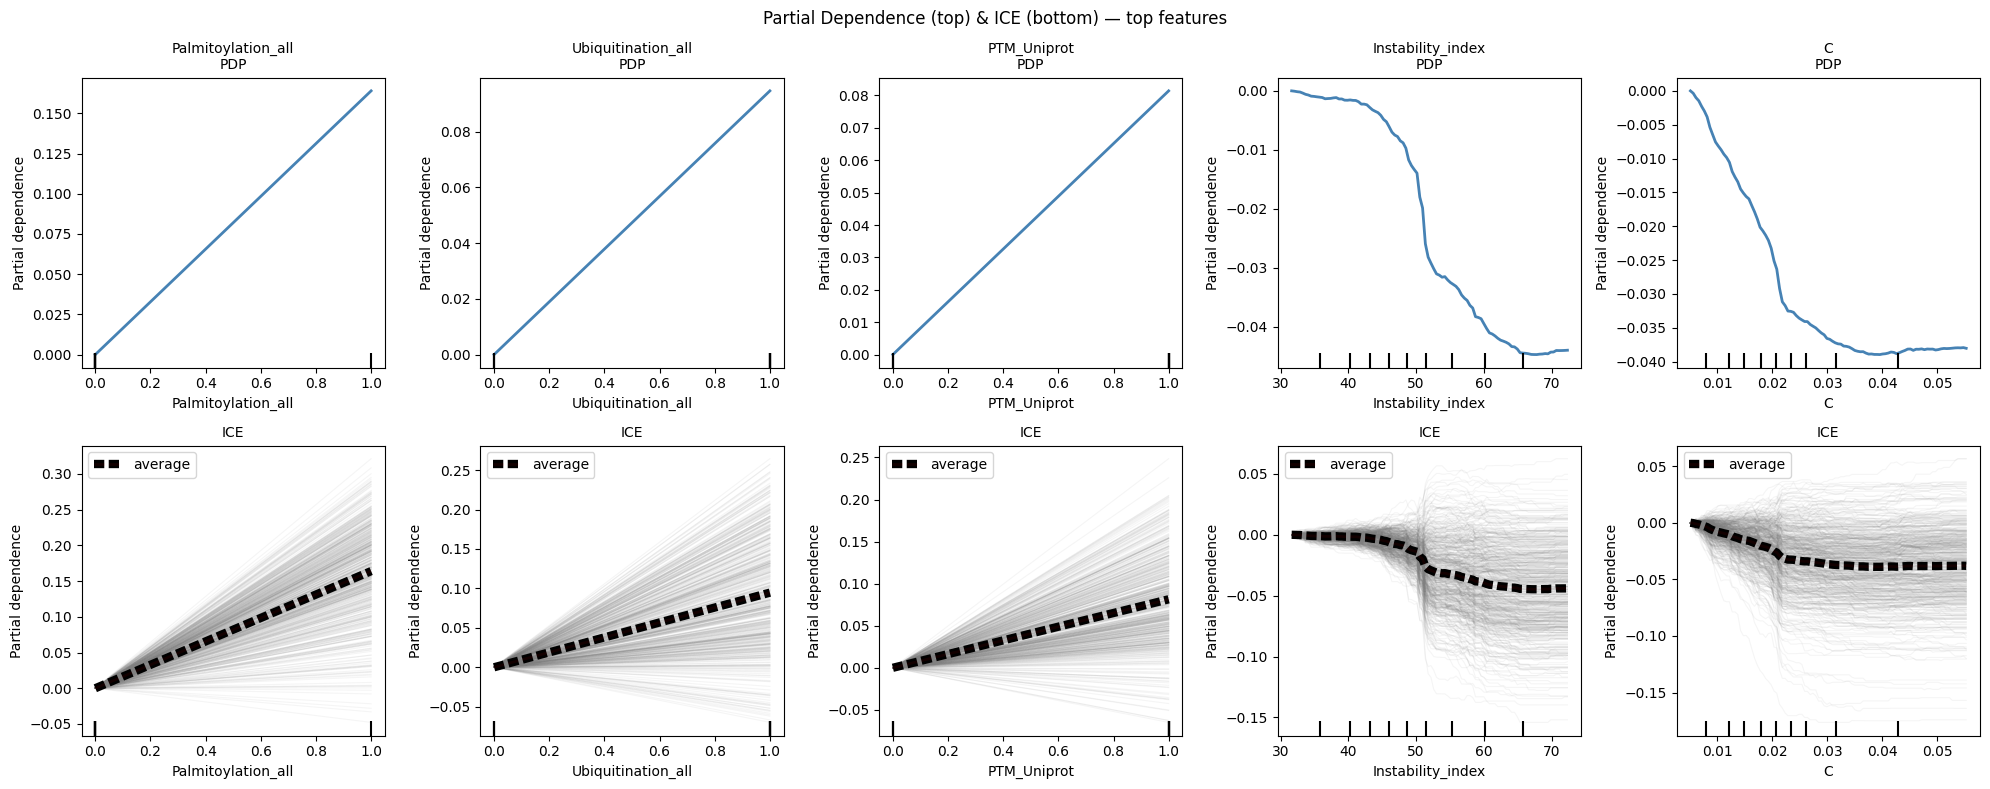

In [81]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Use the top-N most important features for the plots
N_PDP = 5
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:N_PDP]
top_names = [FEATURE_COLS[i] for i in top_idx]
print(f"\nPDP/ICE on top-{N_PDP} features: {top_names}")

# Use a random subsample of training data as background (faster, less clutter)
rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X_train), size=min(500, len(X_train)), replace=False)
X_bg = X_train[bg_idx]

fig, axes = plt.subplots(2, N_PDP, figsize=(4 * N_PDP, 8))

for col, (feat_i, feat_name) in enumerate(zip(top_idx, top_names)):


    # --- PDP (top row) ---
    PartialDependenceDisplay.from_estimator(
        rf_model, X_bg,
        features=[feat_i],
        feature_names=FEATURE_COLS,
        kind="average",          # pure PDP
        ax=axes[0, col],
        line_kw={"color": "steelblue", "lw": 2},
        centered=True,
    )
    axes[0, col].set_title(f"{feat_name}\nPDP", fontsize=10)
    axes[0, col].set_xlabel("")

    # --- ICE + mean overlay (bottom row) ---
    PartialDependenceDisplay.from_estimator(
        rf_model, X_bg,
        features=[feat_i],
        feature_names=FEATURE_COLS,
        kind="both",             # ICE lines + mean PDP in one call
        ax=axes[1, col],
        line_kw={"alpha": 0.08, "color": "grey", "lw": 0.8},
        pd_line_kw={"color": "red", "lw": 2, "zorder": 5,
                    "path_effects": [
                        __import__("matplotlib.patheffects", fromlist=["withStroke"])
                        .withStroke(linewidth=6, foreground="black")
                    ]},
        centered=True,
    )
    axes[1, col].set_title("ICE", fontsize=10)
    axes[1, col].set_xlabel("")

axes[0, 0].set_ylabel("P(EV)")
axes[1, 0].set_ylabel("P(EV)")

# Fix y-axis limits to [-0.35, 0.35] for all axes after plotting
for ax in axes[0]:
    ax.set_ylim(-0.35, 0.35)
for ax in axes[1]:
    ax.set_ylim(-0.35, 0.35)

fig.suptitle("Partial Dependence (top) & ICE (bottom) — top features", fontsize=12)
plt.tight_layout()
plt.show()

**Q5.** Compare the PDP and ICE plots for each feature.
- Where do the ICE curves *spread out* compared to the PDP? What does that spread tell you?
- For which feature(s) does the PDP look like a flat line but the ICE shows strong individual effects? This is a sign of a **subgroup** structure — some proteins respond strongly while others don't.
- Do you find PDP reliable for the top 5 features? If yes, for which one(s)?

> *Your answer here*


### 3.3 Accumulated Local Effects (ALE)

ALE avoids the PDP/ICE problem of unrealistic feature combinations. Instead of varying a feature for *every* protein, it only looks at small intervals and averages the local effect *within* that interval — so it stays close to the real data distribution. For biology, where features are heavily correlated (e.g. many amino acid frequencies sum to 1), ALE is often more trustworthy than PDP.


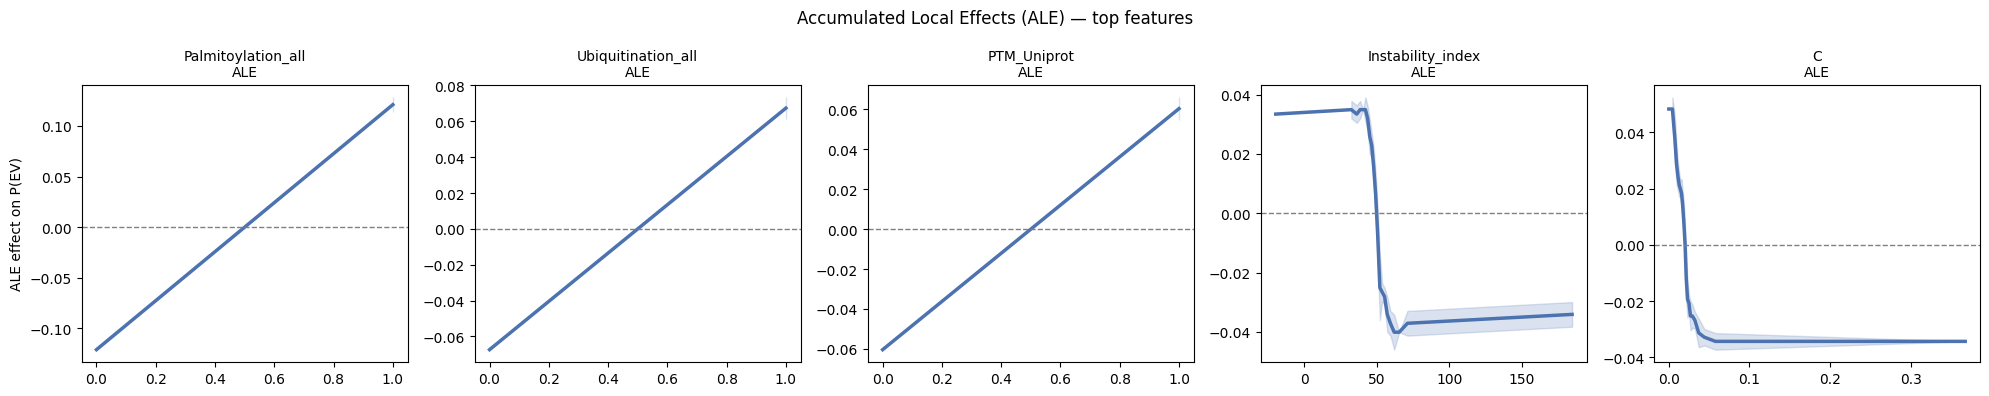

In [90]:
import PyALE
 
N_ALE = N_PDP
ale_idx = top_idx[:N_ALE]
ale_names = [FEATURE_COLS[i] for i in ale_idx]
df_train_for_ale = pd.DataFrame(X_train, columns=FEATURE_COLS)

ale_results = []
for feat_name in ale_names:
    res = PyALE.ale(
        X=df_train_for_ale,
        model=rf_model,
        feature=[feat_name],
        feature_type="continuous",
        include_CI=True,
        C=0.95,
        plot=False,
    )
    ale_results.append((feat_name, res))

fig_ale, axes_ale = plt.subplots(1, N_ALE, figsize=(4 * N_ALE, 4), squeeze=False)
axes_ale = axes_ale.ravel()

for ax, (feat_name, ale_res) in zip(axes_ale, ale_results):
    ale_x = ale_res.index.values
    ale_eff = ale_res["eff"].values
    ale_low = ale_res["lowerCI_95%"].values if "lowerCI_95%" in ale_res.columns else ale_eff
    ale_high = ale_res["upperCI_95%"].values if "upperCI_95%" in ale_res.columns else ale_eff

    ax.plot(ale_x, ale_eff, color="#4C72B0", lw=2.5)
    ax.fill_between(ale_x, ale_low, ale_high, alpha=0.2, color="#4C72B0")
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{feat_name}\nALE", fontsize=10)
    ax.set_xlabel("")

axes_ale[0].set_ylabel("ALE effect on P(EV)")

fig_ale.suptitle("Accumulated Local Effects (ALE) — top features", fontsize=12)
plt.tight_layout()
plt.show()

**Q6.** Compare the PDP and ALE plots for the same features. Do they tell the same story?

If they differ, consider: which features are most correlated with the feature being plotted? (Check your correlation heatmap from Section 1.4.) When features are strongly correlated, PDP can be misleading — it evaluates the model on inputs that never occur in real proteins.

> *Your answer here*


---
## Section 4: LIME — Local Interpretable Model-Agnostic Explanations <a id='lime'></a>

LIME explains **one prediction at a time**. For a protein you want to understand, LIME:
1. Creates many slightly perturbed copies of that protein (changing feature values)
2. Asks the model for predictions on all those perturbed copies
3. Weights perturbed copies by their distance to the original protein (closer = higher weight)
4. Fits a simple **sparse linear model** on the weighted perturbed dataset
5. The coefficients of that linear model are the feature attributions

LIME is **model-agnostic** — it treats any model as a black box and only calls `predict_proba`.

We will use the **Random Forest** as our primary model in this section (also try the MLP if you want).

---

### 4.1 Setting up the LIME explainer and helper functions

The `LimeTabularExplainer` needs:
- Training data (to understand feature distributions and ranges)
- Feature names and mode (`classification` or `regression`)
- Class names (for display)

Check `make_lime_explainer` helper function

In [95]:
# Use one fixed split for LIME analysis to keep experiments comparable
X_lime = X_test
y_lime = y_test
rf_probs_lime = rf_model.predict_proba(X_lime)[:, 1]

# Select representative samples for analysis
ev_mask = y_lime == 1
nonev_mask = y_lime == 0

tp_candidates = np.where((rf_probs_lime >= 0.7) & ev_mask)[0]
fn_candidates = np.where((rf_probs_lime < 0.4) & ev_mask)[0]
tn_candidates = np.where((rf_probs_lime < 0.3) & nonev_mask)[0]

tp_idx = int(tp_candidates[0]) if len(tp_candidates) else int(np.where(ev_mask)[0][np.argmax(rf_probs_lime[ev_mask])])
fn_idx = int(fn_candidates[0]) if len(fn_candidates) else int(np.where(ev_mask)[0][np.argmin(rf_probs_lime[ev_mask])])
tn_idx = int(tn_candidates[0]) if len(tn_candidates) else int(np.where(nonev_mask)[0][np.argmin(rf_probs_lime[nonev_mask])])

sample_indices = {"TP": tp_idx, "FN": fn_idx, "TN": tn_idx}
for tag, idx in sample_indices.items():
    print(f"{tag} sample idx={idx:4d} | y={y_lime[idx]} | P(EV)={rf_probs_lime[idx]:.3f}")


#### LIME explanation and fidelity evaluation functions ####

def make_lime_explainer(kernel_width=None, seed=42):
    return LimeTabularExplainer(
        training_data=X_train,
        feature_names=FEATURE_COLS,
        class_names=["non-EV", "EV"],
        mode="classification",
        kernel_width=kernel_width,
        discretize_continuous=True,
        random_state=seed,
    )


def collapse_lime_weights(exp, label=1):
    """Map bin-level LIME terms back to base feature names and sum bin contributions."""
    collapsed = {}
    for feat_str, w in exp.as_list(label=label):
        matched = False
        for fname in FEATURE_COLS:
            if fname in feat_str:
                collapsed[fname] = collapsed.get(fname, 0.0) + float(w)
                matched = True
                break
        if not matched:
            collapsed[feat_str] = collapsed.get(feat_str, 0.0) + float(w)
    return collapsed


def explanation_weight_vector(exp, label=1):
    """Build dense linear surrogate weights from collapsed LIME explanation."""
    collapsed = collapse_lime_weights(exp, label=label)
    w_vec = np.zeros(len(FEATURE_COLS), dtype=float)
    for i, fname in enumerate(FEATURE_COLS):
        w_vec[i] = collapsed.get(fname, 0.0)
    return w_vec


def compute_lime_fidelity(instance, num_features=15, num_samples=1000, seed=42, n_eval=250):
    """Fidelity on perturbed neighborhood: Pearson r + MAE (surrogate vs black box)."""
    explainer = make_lime_explainer(seed=seed)
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=rf_model.predict_proba,
        num_features=num_features,
        num_samples=num_samples,
    )

    rng_local = np.random.default_rng(seed)
    scale = np.std(X_train, axis=0)
    scale[scale == 0] = 1.0
    perturbed = instance + rng_local.normal(0, 1, size=(n_eval, instance.shape[0])) * scale * 0.5

    bb_preds = rf_model.predict_proba(perturbed)[:, 1]
    w_vec = explanation_weight_vector(exp, label=1)
    intercept = float(exp.intercept[1]) if hasattr(exp, "intercept") and len(exp.intercept) > 1 else 0.0
    surrogate = np.clip(perturbed @ w_vec + intercept, 0, 1)

    corr = float(np.corrcoef(bb_preds, surrogate)[0, 1])
    mae = float(np.mean(np.abs(bb_preds - surrogate)))
    local_pred = float(exp.local_pred[0]) if hasattr(exp, "local_pred") else np.nan
    return corr, mae, local_pred




TP sample idx=   9 | y=1 | P(EV)=0.787
FN sample idx=   4 | y=1 | P(EV)=0.283
TN sample idx=   3 | y=0 | P(EV)=0.216


### 4.2 Let's visualize the explanation for one instance

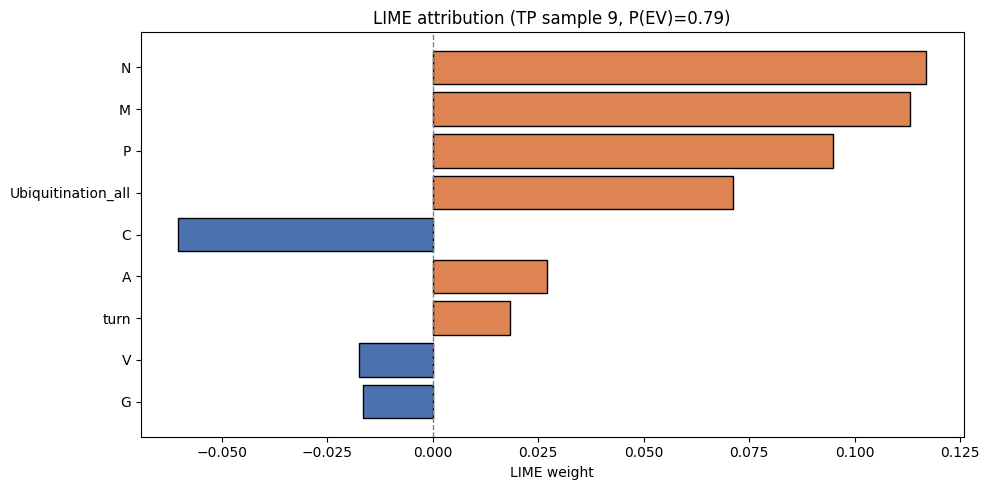

Top TP attribution terms:
  N                                   +0.1170
  M                                   +0.1131
  P                                   +0.0949
  Ubiquitination_all                  +0.0711
  C                                   -0.0604
  A                                   +0.0271
  turn                                +0.0183
  V                                   -0.0174


In [96]:
# 1) Feature attribution visualization (single sample)
NUM_FEATURES_LIME = 15
NUM_SAMPLES_LIME = 1000
DEFAULT_KW = np.sqrt(len(FEATURE_COLS)) * 0.75

explainer_default = make_lime_explainer(kernel_width=DEFAULT_KW, seed=42)
exp_tp = explainer_default.explain_instance(
    data_row=X_lime[tp_idx],
    predict_fn=rf_model.predict_proba,
    num_features=NUM_FEATURES_LIME,
    num_samples=NUM_SAMPLES_LIME,
)

tp_weights = collapse_lime_weights(exp_tp, label=1)
tp_items = sorted(tp_weights.items(), key=lambda x: abs(x[1]), reverse=True)[:12]
labels_tp = [k for k, _ in tp_items][::-1]
vals_tp = [v for _, v in tp_items][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels_tp, vals_tp, color=["#DD8452" if v > 0 else "#4C72B0" for v in vals_tp], edgecolor="black")
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_title(f"LIME attribution (TP sample {tp_idx}, P(EV)={rf_probs_lime[tp_idx]:.2f})")
ax.set_xlabel("LIME weight")
plt.tight_layout()
plt.show()

print("Top TP attribution terms:")
for feat, w in tp_items[:8]:
    print(f"  {feat:<35s} {w:+.4f}")

**Q4.** Which features are most important according for this specific instance?

> *Your answer here*

### 4.3 LIME instability problem

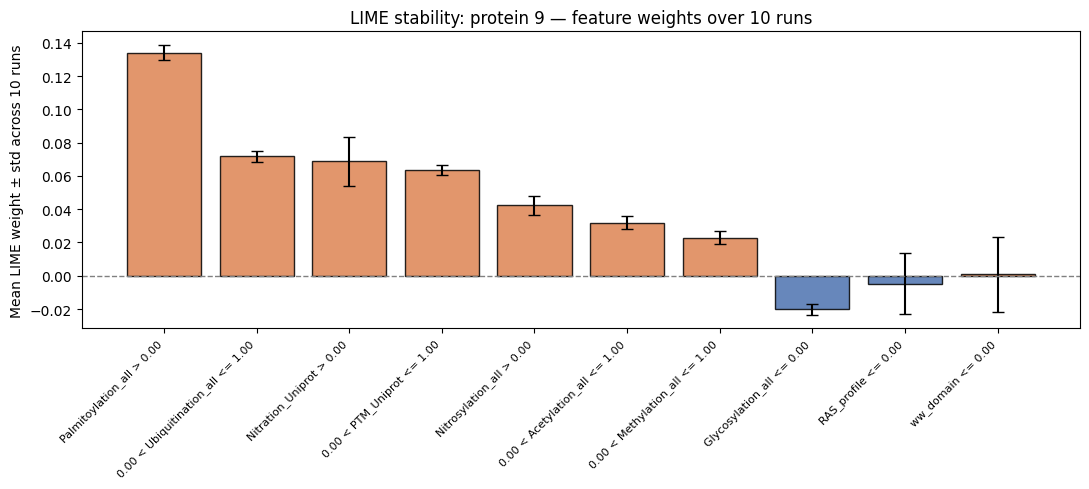

Top-10 feature overlap between run 0 and run 9: 8/10


In [125]:
# ── 4.7  LIME stability across random seeds ───────────────────────────────────
N_RUNS = 10
TOP_N  = 10    # compare top-10 features across runs

run_weights = {}   # feat_name -> list of weights across runs

for run in range(N_RUNS):
    exp_run = LimeTabularExplainer(
        training_data         = X_train,
        feature_names         = FEATURE_COLS,
        class_names           = ["Non-EV", "EV"],
        mode                  = "classification",
        discretize_continuous = True,
        random_state          = run   # different seed each run
    ).explain_instance(
        data_row     = X_test[tp_idx],
        predict_fn   = rf_model.predict_proba,
        num_features = TOP_N,
        num_samples  = 1000,
    )
    for feat_str, weight in exp_run.as_list(label=1):
        run_weights.setdefault(feat_str, []).append(weight)

# Build summary: features that appear in at least half the runs
stable_feats = {k: v for k, v in run_weights.items() if len(v) >= N_RUNS // 2}
feat_means   = {k: np.mean(v) for k, v in stable_feats.items()}
feat_stds    = {k: np.std(v)  for k, v in stable_feats.items()}
sorted_feats = sorted(feat_means.items(), key=lambda x: abs(x[1]), reverse=True)[:15]

fig, ax = plt.subplots(figsize=(11, 5))
names  = [f[0][:45] for f in sorted_feats]
means  = [f[1] for f in sorted_feats]
stds   = [feat_stds.get(f[0], 0) for f in sorted_feats]
x_pos  = range(len(names))

bars = ax.bar(x_pos, means, yerr=stds, capsize=4,
              color=["#DD8452" if m > 0 else "#4C72B0" for m in means],
              edgecolor="black", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean LIME weight ± std across 10 runs")
ax.set_title(f"LIME stability: protein {tp_idx} — feature weights over {N_RUNS} runs")
ax.axhline(0, color="gray", lw=1, ls="--")
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("lime_stability.png", dpi=120, bbox_inches="tight")
plt.show()

# Compute rank overlap between first and last run
# (a simple way to measure ordering stability)
run0_feats = [f for f, _ in sorted(run_weights.items(),
              key=lambda x: abs(x[1][0]) if x[1] else 0, reverse=True)[:TOP_N]]
run9_feats = [f for f, _ in sorted(run_weights.items(),
              key=lambda x: abs(x[1][-1]) if len(x[1]) > 1 else 0, reverse=True)[:TOP_N]]
overlap = len(set(run0_feats) & set(run9_feats))
print(f"Top-{TOP_N} feature overlap between run 0 and run 9: {overlap}/{TOP_N}")


**Q11.** Looking at the error bars:
- Which features are *stable* across runs (small error bar)?
- Which features are *unstable* (large error bar)?
- What does instability mean for a biologist trying to prioritise features for follow-up experiments?
- How could you reduce instability without changing the model? (Hint: which parameter from Section 4.3?)

> *Your answer here*

---

> ✏️ **STUDENT TASK 4.8:** Run the stability analysis for the MLP instead of the Random Forest. Does the MLP give more or less stable LIME explanations? Why might that be?


### 4.3 Effect of number of perturbations (`num_samples`)

The number of perturbations controls how well LIME estimates the local decision boundary. Too few samples → noisy linear fit → unreliable attributions. Too many → slow but more stable.


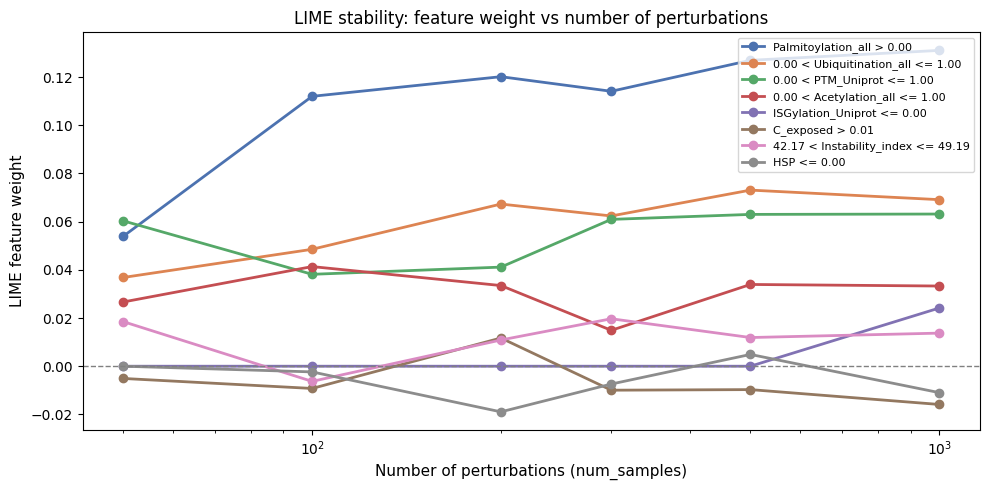

In [116]:
# ── 4.3  Effect of num_samples on LIME explanation ───────────────────────────
sample_sizes = [50, 100, 200, 300, 500, 1000]
TOP_FEAT_NAME = FEATURE_COLS[order[0]]   # most important feature from permutation importance

lime_weights_by_n = {}

for n in sample_sizes:
    exp = explainer_default.explain_instance(
        data_row     = X_test[tp_idx],
        predict_fn   = rf_model.predict_proba,
        num_features = len(FEATURE_COLS),
        num_samples  = n,
    )
    weights_dict = dict(exp.as_list(label=1))
    lime_weights_by_n[n] = weights_dict

# Track the weight of 8 features across sample sizes
feat_count = 8 
TRACK_FEATS_PARTIAL = [f for f in lime_weights_by_n[1000].keys()
                        if any(tf in f for tf in [FEATURE_COLS[order[i]] for i in range(feat_count)])][:feat_count]
if not TRACK_FEATS_PARTIAL:
    TRACK_FEATS_PARTIAL = list(lime_weights_by_n[1000].keys())[:feat_count]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]
for feat, color in zip(TRACK_FEATS_PARTIAL, colors):
    vals = [lime_weights_by_n[n].get(feat, np.nan) for n in sample_sizes]
    ax.plot(sample_sizes, vals, "o-", color=color, lw=2, label=feat[:40])

ax.set_xscale("log")
ax.set_xlabel("Number of perturbations (num_samples)", fontsize=11)
ax.set_ylabel("LIME feature weight", fontsize=11)
ax.set_title("LIME stability: feature weight vs number of perturbations", fontsize=12)
ax.legend(fontsize=8, loc="upper right")
ax.axhline(0, color="gray", lw=1, ls="--")
plt.tight_layout()
plt.show()


**Q8.** How different number of perturbations can affect the feature importance in LIME? can this be resolved?

**Q9.** Can you repeat exeucting this cell? Do we see the same plot? 
 
> *Your answer here*


### 4.4 Effect of kernel width (distance / neighborhood size)

LIME uses a **kernel function** to weight perturbations by their distance to the original sample. Closer perturbations get higher weight. The **kernel width** controls the *size* of the local neighborhood:

- **Small kernel width** → only very nearby perturbations count → very local, but noisy
- **Large kernel width** → distant perturbations also count → smoother, but loses locality

In `lime`, the kernel width can be set via the `kernel_width` parameter of `LimeTabularExplainer`. The default is `np.sqrt(n_features) * 0.75`.


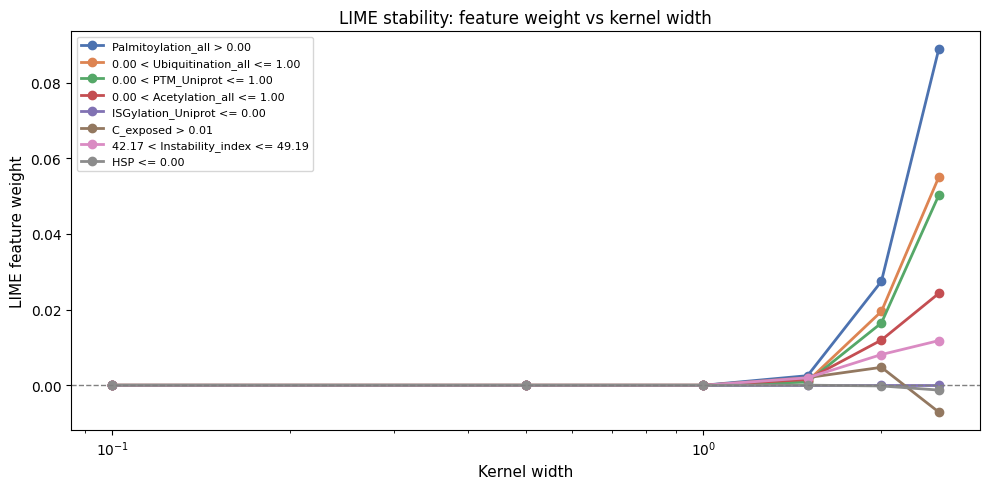

Default kernel width: 7.23


In [119]:
# ── 4.4  Effect of kernel_width on LIME explanation ──────────────────────────
kernel_widths = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5]
lime_weights_by_kw = {}

for kw in kernel_widths:
    exp_kw = LimeTabularExplainer(
        training_data         = X_train,
        feature_names         = FEATURE_COLS,
        class_names           = ["Non-EV", "EV"],
        mode                  = "classification",
        kernel_width          = kw,
        discretize_continuous = True,
        random_state          = SEED
    ).explain_instance(
        data_row     = X_test[tp_idx],
        predict_fn   = rf_model.predict_proba,
        num_features = len(FEATURE_COLS),
        num_samples  = 1000,
    )
    lime_weights_by_kw[kw] = dict(exp_kw.as_list(label=1))

# Track same 3 features
fig, ax = plt.subplots(figsize=(10, 5))
for feat, color in zip(TRACK_FEATS_PARTIAL, colors):
    vals = [lime_weights_by_kw[kw].get(feat, np.nan) for kw in kernel_widths]
    ax.plot(kernel_widths, vals, "o-", color=color, lw=2, label=feat[:40])

ax.set_xscale("log")
ax.set_xlabel("Kernel width", fontsize=11)
ax.set_ylabel("LIME feature weight", fontsize=11)
ax.set_title("LIME stability: feature weight vs kernel width", fontsize=12)
ax.legend(fontsize=8)
ax.axhline(0, color="gray", lw=1, ls="--")
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("lime_kernel_width.png", dpi=120, bbox_inches="tight")
plt.show()

default_kw = np.sqrt(len(FEATURE_COLS)) * 0.75
print(f"Default kernel width: {default_kw:.2f}")


**Q10.** How do the feature attributions change as you increase the kernel width?
- At very small kernel width, why might the explanation be noisy?
- At very large kernel width, the local linear model effectively approximates the *global* behavior — is that still useful?
- Relate this to the LIME limitation discussed in the lecture: "There is no principled rule for choosing this width."

> *Your answer here*


---
## Section 5: SHAP — Kernel SHAP <a id='shap-ag'></a>

SHAP (SHapley Additive exPlanations) computes **Shapley values** for each feature and prediction. Unlike LIME, SHAP is grounded in game theory: it is the *unique* attribution method satisfying four fairness axioms (efficiency, symmetry, null player, linearity).

In this notebook, we focus on **Kernel SHAP** as the model-agnostic SHAP method. It requires a **background dataset** — samples used to marginalize out features that are "absent" from a coalition. The choice and size of the background dataset directly affects the SHAP values, so we will explore that carefully.

---

### 5.1 Effect of background sample size

A key practical question: *how many background samples do we need?* More background samples → more accurate marginalization → more reliable SHAP values, but slower computation.

We will use **Kernel SHAP** for this experiment because its results are especially sensitive to background sample size.



1. Kernel SHAP — background size sensitivity


100%|██████████| 1/1 [00:00<00:00, 14.25it/s]


  bg_size=  10  done


100%|██████████| 1/1 [00:00<00:00, 14.08it/s]


  bg_size=  25  done


...

  bg_size= 300  done


100%|██████████| 1/1 [00:00<00:00,  3.15it/s]
shap:WARNING: Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  bg_size= 500  done


100%|██████████| 1/1 [00:00<00:00,  1.82it/s]

  bg_size=1000  done


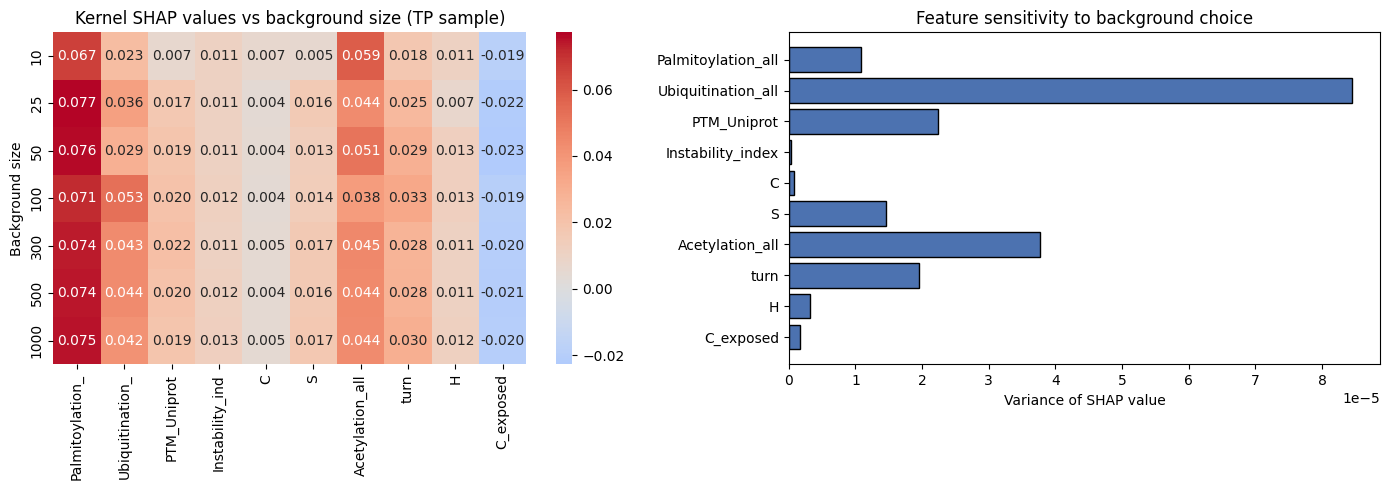

In [128]:
print("\n1. Kernel SHAP — background size sensitivity")
background_sizes_shap = [10, 25, 50, 100, 300, 500, 1000]
shap_by_bg = {}

# Use top-10 features to reduce computation time
top_10_idx = np.argsort(rf_model.feature_importances_)[::-1][:10]
top_10_names = [FEATURE_COLS[i] for i in top_10_idx]
instance_top10 = X_lime[tp_idx:tp_idx + 1, :][:, top_10_idx]

def rf_predict_top10(X_sub):
    """Insert top-10 features into full feature space."""
    full = np.tile(X_lime[tp_idx], (X_sub.shape[0], 1))
    full[:, top_10_idx] = X_sub
    return rf_model.predict_proba(full)[:, 1]

for bg_size in background_sizes_shap:
    rng_bg = np.random.default_rng(42)
    bg_idx = rng_bg.choice(len(X_train), size=bg_size, replace=False)
    background_sub = X_train[bg_idx, :][:, top_10_idx]
    
    explainer_k = shap.KernelExplainer(rf_predict_top10, background_sub)
    sv = explainer_k.shap_values(instance_top10, nsamples=256)
    shap_by_bg[bg_size] = sv
    print(f"  bg_size={bg_size:4d}  done")

# Plot: SHAP sensitivity to background size
shap_matrix = np.array([shap_by_bg[s].flatten() for s in background_sizes_shap])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    shap_matrix,
    annot=True, fmt=".3f", cmap="coolwarm", center=0,
    xticklabels=[f[:15] for f in top_10_names],
    yticklabels=[str(s) for s in background_sizes_shap],
    ax=axes[0]
)
axes[0].set_title("Kernel SHAP values vs background size (TP sample)")
axes[0].set_ylabel("Background size")

feature_variances = shap_matrix.var(axis=0)
axes[1].barh([f[:25] for f in top_10_names[::-1]], feature_variances[::-1],
             color="#4C72B0", edgecolor="black")
axes[1].set_title("Feature sensitivity to background choice")
axes[1].set_xlabel("Variance of SHAP value")

plt.tight_layout()
plt.show()

**Q12.**
1. Which features show the highest variance in SHAP values across different background sizes? What does that tell you about those features?
2. Why does the background sample matter? (Recall: Kernel SHAP marginalizes out "absent" features by replacing them with background values. What happens if the background is very small and unrepresentative?)
3. The lecture slide "Sanity-checking your explanations" recommended: "Re-run with different background samples — stable rankings ⇒ enough samples." Based on your results, what background size seems sufficient for this dataset?

> *Your answer here*


### 5.2 Kernel SHAP

Kernel SHAP reformulates Shapley value computation as a **weighted linear regression**. It is mathematically connected to local surrogate explanations, but uses the Shapley kernel to recover feature attributions with a stronger game-theoretic foundation.

Recall from the lecture: Kernel SHAP is closely related to LIME, but replaces the locality weighting and sparse regression setup with the Shapley kernel formulation.


Computing Kernel SHAP…


100%|██████████| 100/100 [00:11<00:00,  8.49it/s]


Kernel SHAP done in 11.8 s  |  shape: (100, 93, 2)


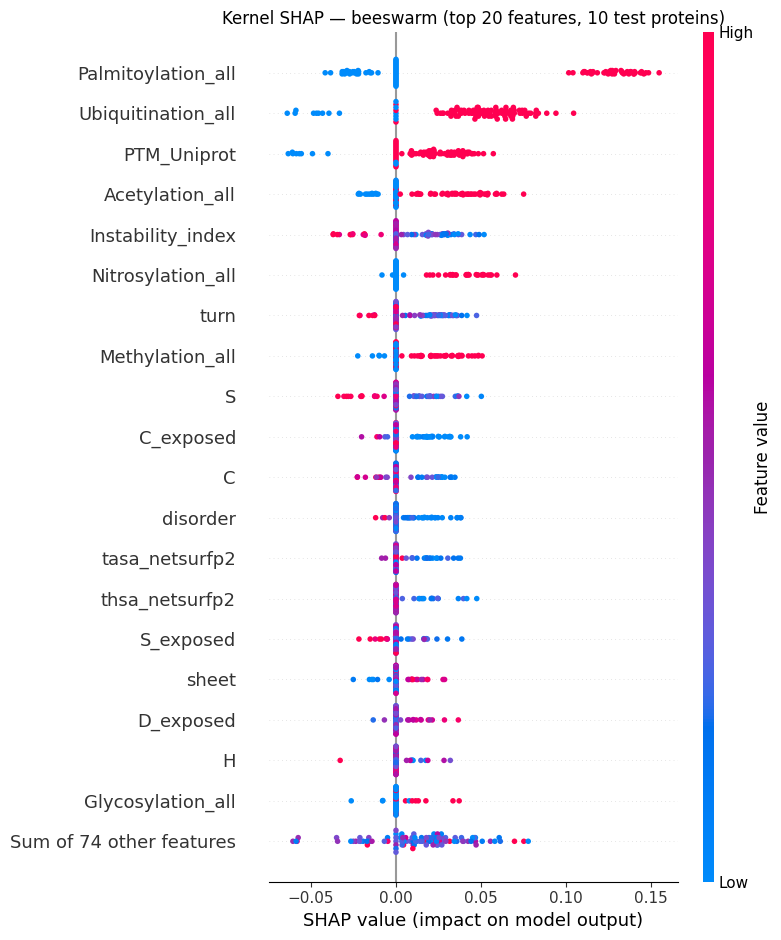

In [134]:
# ── 5.2  Kernel SHAP ─────────────────────────────────────────────────────────
# We explain a subset of test proteins for speed.
EXPLAIN_IDX = np.random.default_rng(SEED).choice(len(X_test), size=100, replace=False)
X_explain   = X_test[EXPLAIN_IDX]

# Background: 100 training samples (good balance of accuracy vs speed)
bg_idx_100 = np.random.default_rng(SEED).choice(len(X_train), size=100, replace=False)
background_100 = X_train[bg_idx_100]

print("Computing Kernel SHAP…")
t0 = time.time()

kernel_explainer = shap.KernelExplainer(
    model  = rf_model.predict_proba,
    data   = background_100,
    link   = "identity"
)

shap_kernel = kernel_explainer.shap_values(X_explain, nsamples=256)
shap_kernel_ev = shap_kernel[1] if isinstance(shap_kernel, list) else shap_kernel

t_kernel = time.time() - t0
print(f"Kernel SHAP done in {t_kernel:.1f} s  |  shape: {shap_kernel_ev.shape}")


shap_exp_kernel = shap.Explanation(
    values        = shap_kernel_ev,
    base_values   = kernel_explainer.expected_value[1] if hasattr(kernel_explainer.expected_value, '__len__') else kernel_explainer.expected_value,
    data          = X_explain,
    feature_names = FEATURE_COLS
)

class_index = 1
sv_class = shap_exp_kernel[:,:,class_index]

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(sv_class, max_display=20, show=False)
plt.title("Kernel SHAP — beeswarm (top 20 features, 10 test proteins)", fontsize=12)
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("shap_kernel_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()


**Q13.**



---
### Section 5.3: SHAP — Model-Specific Methods <a id='shap-sp'></a>

Model-agnostic SHAP variants (Kernel, Sampling, Permutation) treat the model as a black box. When we *know* the model architecture, we can exploit it for faster and more exact Shapley values:

| Method | Model | Speed | Exact? |
|--------|-------|-------|--------|
| **TreeSHAP** | Tree ensembles (RF, XGBoost, LightGBM) | Very fast (polynomial time) | Yes |
| **DeepSHAP** | Neural networks (PyTorch, TensorFlow) | Fast (gradient-based) | Approx. |

In the lecture, we highlighted two key advantages of model-specific SHAP:
1. **Speed**: TreeSHAP is orders of magnitude faster than Kernel SHAP for large forests
2. **Reliability**: TreeSHAP is exact; it does not depend on background sample size

---

### 6.1 TreeSHAP for Random Forest

TreeSHAP exploits the tree structure: by walking the decision paths, it can compute exact Shapley values for every sample *without* any sampling approximation.


In [135]:
# ── 6.1  TreeSHAP for Random Forest ──────────────────────────────────────────
samples_tbx_idx   = np.random.default_rng(SEED).choice(len(X_test), size=100, replace=False)
samples_tbx = X_test[samples_tbx_idx]

print("Computing TreeSHAP…")
t0_tree = time.time()

tree_explainer = shap.TreeExplainer(
    model           = rf_model,
    feature_perturbation = "tree_path_dependent"  # exact, no background needed
)

# Explain the full test set
shap_tree = tree_explainer.shap_values(samples_tbx)
# For RandomForestClassifier, shap_values returns a list [class0, class1]
shap_tree_ev = shap_tree[1] if isinstance(shap_tree, list) else shap_tree

t_tree = time.time() - t0_tree
print(f"TreeSHAP done in {t_tree:.2f} s  |  shape: {shap_tree_ev.shape}")
print(f"  (Computed for {len(X_test)} proteins with {len(FEATURE_COLS)} features each)")


Computing TreeSHAP…
TreeSHAP done in 3.14 s  |  shape: (100, 93, 2)
  (Computed for 1426 proteins with 93 features each)


**Q14.** Is TreeSHAP is faster than Kernel SHAP? how much?
> *Your answer here*

In [133]:
# ── 6.1b  TreeSHAP: global and local visualizations ──────────────────────────
shap_exp_tree = shap.Explanation(
    values        = shap_tree_ev,
    base_values   = tree_explainer.expected_value[1] if hasattr(tree_explainer.expected_value, '__len__') else tree_explainer.expected_value,
    data          = samples_tbx,
    feature_names = FEATURE_COLS
)

# # Beeswarm (global)
# class_index = 1
# # shap_tree_ev = shap_exp_tree[:,:,class_index]

plt.figure(figsize=(10, 8))

shap.plots.beeswarm(shap_tree_ev, max_display=20, show=False)
plt.title("TreeSHAP — beeswarm (full test set)", fontsize=12)

plt.tight_layout()
plt.savefig("treeshap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# Waterfall for one protein (true positive)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_tree[tp_idx], max_display=15, show=False)
plt.title(f"TreeSHAP — waterfall (protein {tp_idx}, true positive)")
plt.tight_layout()
# plt.savefig("treeshap_waterfall_tp.png", dpi=120, bbox_inches="tight")
plt.show()

# Bar plot (mean |SHAP|)
plt.figure(figsize=(9, 6))
shap.plots.bar(shap_exp_tree, max_display=20, show=False)
plt.title("TreeSHAP — mean |SHAP| (global importance)", fontsize=12)
plt.tight_layout()
plt.savefig("treeshap_bar.png", dpi=120, bbox_inches="tight")
plt.show()


TypeError: The beeswarm plot requires an `Explanation` object as the `shap_values` argument.

<Figure size 1000x800 with 0 Axes>

In [ ]:
# ── 6.1c  TreeSHAP: dependence plot ──────────────────────────────────────────
# A SHAP dependence plot shows ϕᵢ vs xᵢ across all test proteins.
# The color represents a second feature (automatically chosen as the most
# interacting feature), revealing pairwise interactions.
top1_feat = FEATURE_COLS[np.argsort(np.abs(shap_tree_ev).mean(axis=0))[::-1][0]]

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top1_feat, shap_tree_ev, X_test,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title(f"TreeSHAP dependence plot — {top1_feat}", fontsize=12)
plt.tight_layout()
#plt.savefig("treeshap_dependence.png", dpi=120, bbox_inches="tight")
plt.show()


**Q14.** Interpret the TreeSHAP beeswarm plot:
- Which features push toward EV (positive SHAP)?
- Which push away from EV (negative SHAP)?
- Look at the color coding: for the top feature, do high values (red) increase or decrease the EV probability? Does this match your biological intuition?

**Q15.** Look at the dependence plot:
- What does the shape of the scatter tell you about how the top feature affects predictions?
- The color of each dot represents a second, automatically-selected feature. Where do you see *clustering by color*? That indicates an **interaction** between the two features. Can you interpret this biologically?

> *Your answer here (Q14 + Q15)*


### 6.2 DeepSHAP for the MLP

DeepSHAP combines the Shapley framework with backpropagation (via DeepLIFT). Instead of sampling coalitions, it uses gradients to propagate attributions through the network layers.

**Key requirement:** DeepSHAP needs a set of **background samples** as a reference point. It computes the difference `f(x) - f(background)` and attributes it layer-by-layer.


In [136]:
# ── 6.2  DeepSHAP for the MLP ────────────────────────────────────────────────
# DeepSHAP works with PyTorch tensors.
# We pass the scaled data (as the MLP was trained on scaled inputs).

print("Computing DeepSHAP…")
t0_deep = time.time()

# Background: 100 training samples (scaled).
# bg_idx_100 is defined in Section 5.2; define it here if that section was skipped.
if "bg_idx_100" not in dir():
    bg_idx_100 = np.random.default_rng(SEED).choice(len(X_train), size=100, replace=False)
bg_scaled = torch.tensor(X_train_scaled[bg_idx_100], dtype=torch.float32).to(DEVICE)

# Wrap the MLP so it outputs a single value (probability for EV class)
class MLPForShap(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits = self.model(x)
        return torch.sigmoid(logits).unsqueeze(-1)   # shape: (B, 1)


mlp_shap_wrapper = MLPForShap(mlp).to(DEVICE)
mlp_shap_wrapper.eval()

# Samples to explain (first 50 test proteins, scaled)
X_explain_scaled = torch.tensor(X_test_scaled[:50], dtype=torch.float32).to(DEVICE)

deep_explainer = shap.DeepExplainer(mlp_shap_wrapper, bg_scaled)
shap_deep = deep_explainer.shap_values(X_explain_scaled)

# shap_deep is a list with one element (single output), each shape (N, features)
shap_deep_ev = shap_deep[0] if isinstance(shap_deep, list) else shap_deep

t_deep = time.time() - t0_deep
print(f"DeepSHAP done in {t_deep:.2f} s  |  shape: {np.array(shap_deep_ev).shape}")


Computing DeepSHAP…


AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 0.3637460340105463 - Tolerance: 0.01

In [ ]:
# ── 6.2b  DeepSHAP visualizations ────────────────────────────────────────────
shap_deep_np = np.array(shap_deep_ev)

shap_exp_deep = shap.Explanation(
    values        = shap_deep_np,
    base_values   = deep_explainer.expected_value[0] if hasattr(deep_explainer.expected_value, '__len__') else deep_explainer.expected_value,
    data          = X_test_scaled[:50],
    feature_names = FEATURE_COLS
)

# Beeswarm
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_exp_deep, max_display=20, show=False)
plt.title("DeepSHAP — beeswarm (50 test proteins, MLP)", fontsize=12)
plt.tight_layout()
plt.savefig("deepshap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# Waterfall for a true positive within the first 50 test samples
# (shap_exp_deep only covers X_test[:50]; tp_idx may be outside this range)
_tp50_mask = (rf_probs[:50] >= 0.7) & (y_test[:50] == 1)
_deep_tp_idx = int(np.where(_tp50_mask)[0][0]) if _tp50_mask.any() else 0
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_deep[_deep_tp_idx], max_display=15, show=False)
plt.title(f"DeepSHAP — waterfall (test protein #{_deep_tp_idx}, MLP)")
plt.tight_layout()
plt.savefig("deepshap_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.3 Speed comparison: TreeSHAP vs Kernel SHAP

One of the main selling points of TreeSHAP is speed. We already have the runtimes from above. Let's make the comparison explicit and also scale it to the full test set.


In [ ]:
# ── 6.3  Speed comparison ─────────────────────────────────────────────────────
# We already have t_tree, t_kernel, and t_deep from above.

n_explain = len(X_explain)  # proteins explained with Kernel SHAP

speed_data = {
    "Kernel SHAP\n(10 samples)": t_kernel,
    "TreeSHAP\n(full test set)": t_tree,
    "DeepSHAP\n(50 samples)": t_deep,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors_speed = ["#4C72B0", "#55A868", "#DD8452"]
bars = ax.bar(speed_data.keys(), speed_data.values(),
              color=colors_speed, edgecolor="black")

for bar, val in zip(bars, speed_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}s", ha="center", fontsize=10)

ax.set_ylabel("Wall-clock time (seconds)")
ax.set_title("Runtime comparison: Kernel SHAP vs model-specific SHAP", fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Model-agnostic (Kernel SHAP)"),
    Patch(facecolor="#55A868", label="TreeSHAP (RF — exact)"),
    Patch(facecolor="#DD8452", label="DeepSHAP (MLP — gradient)"),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("shap_speed_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"TreeSHAP computed {len(X_test)} proteins in {t_tree:.2f}s")
print(f"Kernel SHAP computed {n_explain} proteins in {t_kernel:.2f}s")
print(f"Projected Kernel SHAP for {len(X_test)} proteins: "
      f"{t_kernel * len(X_test) / n_explain:.0f}s ≈ "
      f"{t_kernel * len(X_test) / n_explain / 60:.1f} min")


**Q16.**
1. By roughly how many times is TreeSHAP faster than Kernel SHAP for the same number of proteins?
2. The lecture stated that TreeSHAP is **exact** while Kernel SHAP is **approximate**. What does "exact" mean here? (Hint: what property of Shapley values is exactly satisfied?)
3. DeepSHAP is also an approximation — why? (Recall: it uses the *baseline* value function rather than the marginal value function, and approximates at each non-linearity.)

> *Your answer here*


### 6.4 Reliability: TreeSHAP vs Kernel SHAP

Beyond speed, TreeSHAP should give more *reliable* (less variable) results because it is exact — it does not depend on how many background samples you use or how many coalitions you sample.

Let's verify this by comparing the feature rankings from TreeSHAP and Kernel SHAP on the same proteins.


In [ ]:
# ── 6.4  Reliability: TreeSHAP vs Kernel SHAP ────────────────────────────────
# Compare mean |SHAP| rankings on the 50 proteins we explained with both methods.
shap_tree_sub = shap_tree_ev[EXPLAIN_IDX]   # TreeSHAP for the same 50 proteins

mean_tree_sub   = np.abs(shap_tree_sub).mean(axis=0)
mean_kernel_sub = np.abs(shap_kernel_ev).mean(axis=0)

# Spearman rank correlation
r_tk, _ = spearmanr(mean_tree_sub, mean_kernel_sub)
print(f"Spearman rank correlation (TreeSHAP vs Kernel SHAP): r = {r_tk:.4f}")

# Plot comparison
top30_tree   = np.argsort(mean_tree_sub)[::-1][:30]
top30_kernel = np.argsort(mean_kernel_sub)[::-1][:30]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([FEATURE_COLS[i][:30] for i in top30_tree[::-1]],
             mean_tree_sub[top30_tree[::-1]], color="#55A868", edgecolor="black")
axes[0].set_title(f"TreeSHAP — mean |ϕ|\n(exact, 50 proteins)", fontsize=11)
axes[0].set_xlabel("Mean |SHAP value|")

axes[1].barh([FEATURE_COLS[i][:30] for i in top30_kernel[::-1]],
             mean_kernel_sub[top30_kernel[::-1]], color="#DD8452", edgecolor="black")
axes[1].set_title(f"Kernel SHAP — mean |ϕ|\n(approximate, bg=100, 50 proteins)", fontsize=11)
axes[1].set_xlabel("Mean |SHAP value|")

plt.suptitle(f"Feature importance ranking: TreeSHAP vs Kernel SHAP  (Spearman r = {r_tk:.3f})",
             fontsize=12)
plt.tight_layout()
plt.savefig("treeshap_vs_kernel.png", dpi=120, bbox_inches="tight")
plt.show()


**Q17.**
1. Do TreeSHAP and Kernel SHAP agree on the top features? What is the Spearman correlation?
2. For which features do they *disagree* most? Can you think of a reason — are those features correlated with others?
3. In a real biological study, would you prefer TreeSHAP or Kernel SHAP for a Random Forest model? Justify your answer.

> *Your answer here*

---

> ✏️ **STUDENT TASK 6.5:** Compute TreeSHAP SHAP interaction values for the top 10 features using `shap.TreeExplainer` with `model_output='raw'` and `feature_perturbation='tree_path_dependent'`. Then call `tree_explainer.shap_interaction_values(X_test[:100])` and visualize the interaction matrix as a heatmap. Which feature pair shows the strongest interaction? Can you interpret it biologically?


In [ ]:
# ── 7.1  Feature importance consensus ────────────────────────────────────────
# Collect top-10 feature rankings from each method.

# Permutation importance
top10_perm_imp = [FEATURE_COLS[i] for i in order[:10]]

# LIME (mean |weight| across 10 stable runs)
lime_feat_importance = {k: abs(np.mean(v)) for k, v in run_weights.items() if len(v) >= 5}
top10_lime = sorted(lime_feat_importance, key=lime_feat_importance.get, reverse=True)[:10]
# Strip LIME discretisation tags to match feature names
top10_lime_clean = []
for lime_f in top10_lime:
    matched = [f for f in FEATURE_COLS if f in lime_f]
    if matched: top10_lime_clean.append(matched[0])
top10_lime_clean = list(dict.fromkeys(top10_lime_clean))[:10]  # deduplicate

# Kernel SHAP
top10_kernel_shap = [FEATURE_COLS[i] for i in np.argsort(mean_kernel)[::-1][:10]]

# TreeSHAP
mean_tree_all = np.abs(shap_tree_ev).mean(axis=0)
top10_tree_shap = [FEATURE_COLS[i] for i in np.argsort(mean_tree_all)[::-1][:10]]

# Build consensus table
all_methods = {
    "Permutation Importance": top10_perm_imp,
    "LIME (stable avg)":      top10_lime_clean[:10],
    "Kernel SHAP":            top10_kernel_shap,
    "TreeSHAP":               top10_tree_shap,
}

print(f"{'Rank':<5}", end="")
for method in all_methods:
    print(f"  {method:<30}", end="")
print()
print("-" * (5 + 32 * len(all_methods)))

for rank in range(1, 11):
    print(f"{rank:<5}", end="")
    for method, feat_list in all_methods.items():
        feat = feat_list[rank-1] if rank <= len(feat_list) else "-"
        print(f"  {feat:<30}", end="")
    print()

# Which features appear in top-10 of ALL methods?
all_top10_sets = [set(v[:10]) for v in all_methods.values()]
consensus = all_top10_sets[0].intersection(*all_top10_sets[1:])
print(f"\nFeatures in top-10 of ALL methods: {consensus if consensus else '(none)'}")

union_top10 = all_top10_sets[0].union(*all_top10_sets[1:])
majority = {f for f in union_top10
            if sum(f in s for s in all_top10_sets) >= len(all_methods) // 2 + 1}
print(f"Features in top-10 of majority (≥{len(all_methods)//2+1}/{len(all_methods)}) of methods: {majority}")


**Q18.** Compare the feature rankings across methods:
1. Which features appear in the top-10 of **all** methods? These are the most robust findings.
2. Which features appear in only one method's top-10? Should you trust a feature that only one method identifies as important?
3. Does the consensus list match your biological hypotheses from DAY1-Q3? If not, what did you get wrong — and why?

> *Your answer here*


### 7.4 Method selection guide

As a practical summary, we revisit the method selection question from the lecture.

> ✏️ **STUDENT TASK 7.4:** Fill in the table below based on what you observed in this assignment.
>
> For each method, summarize in your own words the main strength, main weakness, and a scenario in biology where you would recommend using it.

| Method | Main strength | Main weakness | Best use case in biology |
|--------|--------------|---------------|--------------------------|
| Permutation importance | | | |
| PDP | | | |
| ICE | | | |
| ALE | | | |
| LIME | | | |
| Kernel SHAP | | | |
| TreeSHAP | | | |
| DeepSHAP | | | |

> *Fill in the table above*


In [ ]:
# ── 7.5  Final summary figure ─────────────────────────────────────────────────
# A single figure comparing mean feature importance from four key methods side by side.

methods_final = {
    "Permutation\nImportance":  (perm_mean,          FEATURE_COLS),
    "Kernel SHAP\n(approx.)":   (mean_kernel,         FEATURE_COLS),
    "TreeSHAP\n(exact)":        (mean_tree_all,       FEATURE_COLS),
    "DeepSHAP\n(MLP)":          (np.abs(shap_deep_np).mean(axis=0), FEATURE_COLS),
}

# Use top-15 by TreeSHAP as reference
top15_ref = np.argsort(mean_tree_all)[::-1][:15]
feat_labels_final = [FEATURE_COLS[i][:22] for i in top15_ref]

fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, (method_name, (importance, feat_list)), color in zip(axes, methods_final.items(), palette):
    # Normalize to [0,1] for comparability
    vals = importance[top15_ref]
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    ax.barh(feat_labels_final[::-1], vals_norm[::-1], color=color, edgecolor="black", alpha=0.85)
    ax.set_title(method_name, fontsize=11)
    ax.set_xlabel("Normalized importance", fontsize=9)
    ax.axvline(0.5, color="gray", lw=0.5, ls="--")

plt.suptitle("Feature importance consensus — four methods (normalized, top 15 by TreeSHAP)",
             fontsize=13, y=1.02)
plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("final_feature_importance_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Wrap-up

Congratulations — you have applied the full XAI pipeline from the lecture to a real protein biology dataset.

### Key takeaways

1. **Global vs local:** PDP, ALE, and permutation importance describe the model overall. LIME and SHAP explain individual predictions — and those per-protein explanations can differ widely even when global importances look similar.

2. **LIME is intuitive but fragile:** Its results depend on the kernel width, number of perturbations, and random seed. Use large `num_samples`, average across runs, and always check fidelity.

3. **SHAP is principled:** Shapley values satisfy four fairness axioms, making them more theoretically grounded than LIME. But they also depend on the choice of background samples and value function (marginal vs conditional).

4. **TreeSHAP is the practical default for tree models:** It is exact, fast, and does not require background sample tuning. If you are using a Random Forest or XGBoost in your research, always prefer TreeSHAP.

5. **Feature attribution ≠ causation:** A high SHAP value for phosphorylation does not mean phosphorylation *causes* EV sorting — it means the model uses that feature. Biological validation (knockouts, mutants, perturbations) is always necessary.

---

### Exam preparation checklist

Before the oral exam, make sure you can:

- [ ] Explain what PDP, ICE, and ALE each measure and when ALE is preferred over PDP
- [ ] Walk through the LIME pipeline step by step (perturbation, weighting, surrogate, coefficients)
- [ ] Explain the four Shapley axioms in plain English with an example
- [ ] Explain what the background dataset does in Kernel SHAP and why its size matters
- [ ] Explain when to use TreeSHAP vs DeepSHAP vs Kernel SHAP
- [ ] Give one example of how correlated features can mislead LIME or SHAP
- [ ] Describe what "fidelity" means for LIME and why it matters

---

*End of Assignment 1*
